## EDA on Train split

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# نفتح بيانات التدريب فقط!
train_df = pd.read_csv('artifact_3_train.csv')


In [2]:

# نظرة سريعة على أول 3 صفوف
print(train_df.head(3))


                           order_id                       customer_id  \
0  e3c3b6a76ec80dd699ad25f02be1a504  9801ac60f0291d180e5df02015b35f82   
1  29fbef181a9fb4263222cb6a7cc9938d  0657a45b970f96a857e7fb73053306ba   
2  b2727344d4f955cb61829ed7f61b12fc  59941cfff43c8432579de4def65e6be6   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2018-07-02 12:00:14  2018-07-02 17:11:10   
1    delivered      2017-11-25 14:17:31  2017-11-25 14:31:00   
2    delivered      2018-08-01 16:30:46  2018-08-01 16:45:11   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2018-07-03 15:56:00           2018-07-10 16:54:44   
1          2017-11-29 17:03:21           2017-12-01 18:42:09   
2          2018-08-03 07:00:00           2018-08-13 19:46:35   

  order_estimated_delivery_date                customer_unique_id  \
0           2018-08-01 00:00:00  5c1722cf39bfce65886808760c6a85e6   
1           2017-12-11 00:00:00  846faea83a00b2cf670d94

In [3]:

# 1. فحص القيم الناقصة
print(train_df.isnull().sum())


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 132
order_delivered_carrier_date     1445
order_delivered_customer_date    2405
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_price                       631
total_freight                     631
items_count                       631
total_payment                       1
payment_installments                1
delivered_date                   2405
estimated_date                      0
is_late                             0
dtype: int64


In [4]:

# معرفة عدد الصفوف والأعمدة وأنواع البيانات والذاكرة المستخدمة
print("--- معلومات الداتاست ---")
print(train_df.info())


--- معلومات الداتاست ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79552 entries, 0 to 79551
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       79552 non-null  object 
 1   customer_id                    79552 non-null  object 
 2   order_status                   79552 non-null  object 
 3   order_purchase_timestamp       79552 non-null  object 
 4   order_approved_at              79420 non-null  object 
 5   order_delivered_carrier_date   78107 non-null  object 
 6   order_delivered_customer_date  77147 non-null  object 
 7   order_estimated_delivery_date  79552 non-null  object 
 8   customer_unique_id             79552 non-null  object 
 9   customer_zip_code_prefix       79552 non-null  int64  
 10  customer_city                  79552 non-null  object 
 11  customer_state                 79552 non-null  object 
 12  total_price          

--- الإحصائيات الرقمية ---
       customer_zip_code_prefix   total_price  total_freight   items_count  \
count              79552.000000  78921.000000   78921.000000  78921.000000   
mean               35177.805096    137.395974      22.880016      1.142738   
std                29799.706308    208.019960      22.073949      0.540516   
min                 1003.000000      0.850000       0.000000      1.000000   
25%                11380.000000     45.900000      13.860000      1.000000   
50%                24435.000000     86.000000      17.180000      1.000000   
75%                58900.000000    149.900000      24.120000      1.000000   
max                99990.000000   7160.000000    1794.960000     20.000000   

       total_payment  payment_installments       is_late  
count   79551.000000          79551.000000  79552.000000  
mean      160.730543              2.928813      0.078716  
std       219.732176              2.715127      0.269296  
min         0.000000              

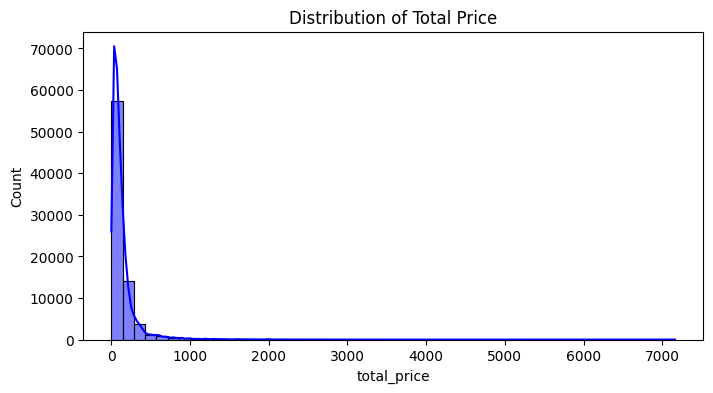

In [5]:
# الإحصائيات الوصفية للأعمدة الرقمية (مثل الأسعار وقيم الدفع)
print("--- الإحصائيات الرقمية ---")
print(train_df.describe())

# رسم توزيع (Distribution) لأحد الأعمدة الرقمية مثل total_price لمعرفة القيم الشاذة (Outliers)
plt.figure(figsize=(8, 4))
sns.histplot(train_df['total_price'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of Total Price')
plt.savefig('artifact_4_price_distribution.png')
plt.show()

In [6]:
# فحص عدد القيم الفريدة (Cardinality) في الأعمدة النصية
print("--- عدد القيم الفريدة لكل عمود تصنيفي ---")
print(train_df.select_dtypes(include=['object']).nunique())

# فحص تكرار قيم عمود معين (مثلاً حالة الطلب order_status)
if 'order_status' in train_df.columns:
    print("\nتوزيع حالات الطلبات:")
    print(train_df['order_status'].value_counts())

--- عدد القيم الفريدة لكل عمود تصنيفي ---
order_id                         79552
customer_id                      79552
order_status                         8
order_purchase_timestamp         79177
order_approved_at                73738
order_delivered_carrier_date     66550
order_delivered_customer_date    76614
order_estimated_delivery_date      454
customer_unique_id               77371
customer_city                     3875
customer_state                      27
delivered_date                   76614
estimated_date                     454
dtype: int64

توزيع حالات الطلبات:
order_status
delivered      77147
shipped          905
canceled         504
unavailable      493
invoiced         256
processing       241
created            4
approved           2
Name: count, dtype: int64


--- متوسط السعر حسب حالة التأخير ---
   is_late  total_price
0        0   136.599366
1        1   146.639154


C:\Users\hp\AppData\Local\Temp\ipykernel_6784\3382302711.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='is_late', y='total_payment', ci=None)


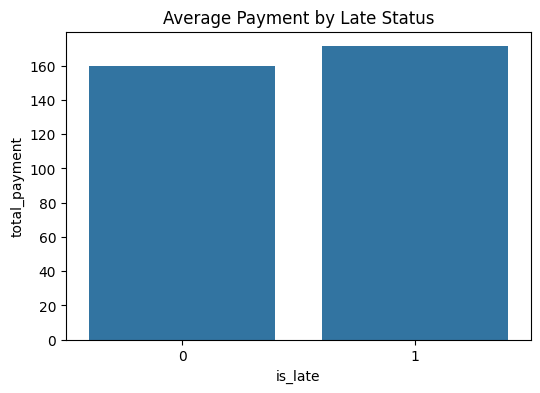

In [7]:
# مثال: هل متوسط السعر يختلف بين الطلبات المتأخرة والسليمة؟
relation_check = train_df.groupby('is_late')['total_price'].mean().reset_index()
print("--- متوسط السعر حسب حالة التأخير ---")
print(relation_check)

# رسم مقارنة يوضح العلاقة
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x='is_late', y='total_payment', ci=None)
plt.title('Average Payment by Late Status')
plt.savefig('artifact_4_payment_vs_late.png')
plt.show()

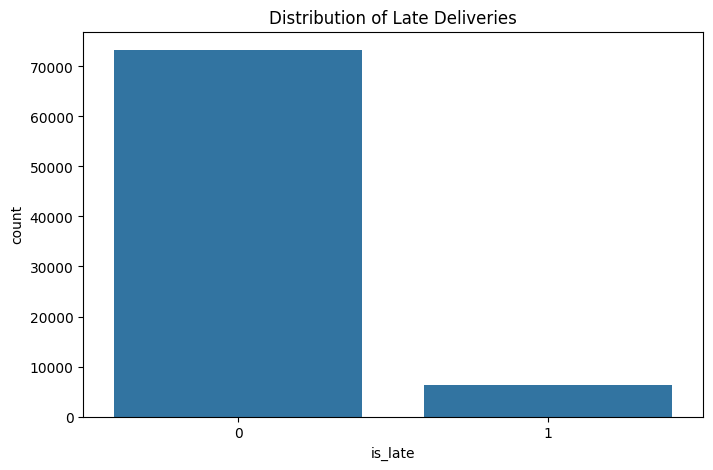

In [8]:


# 2. رسم توزيع التأخير (مثال على استكشاف العلاقات)
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='is_late')
plt.title('Distribution of Late Deliveries')
plt.savefig('artifact_4_label_distribution.png') # حفظ الرسمة كـ Artifact




C:\Users\hp\AppData\Local\Temp\ipykernel_6784\3251926661.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='purchase_dayofweek', y='is_late', ci=None)


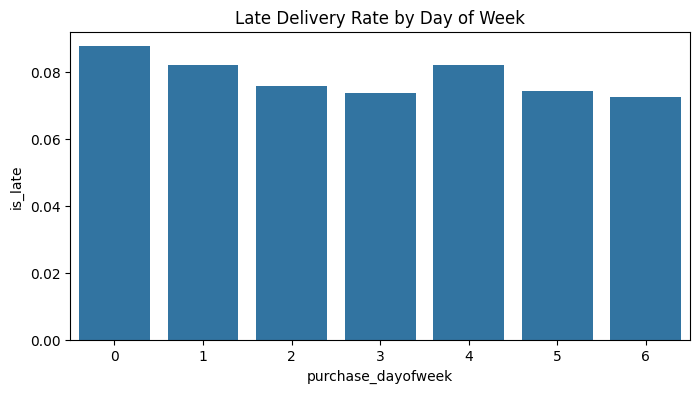

In [9]:
# تحويل أعمدة التواريخ إلى datetime إذا لم تكن محولة
train_df['order_purchase_timestamp'] = pd.to_datetime(train_df['order_purchase_timestamp'])

# استخراج يوم الأسبوع للطلب (0 = الإثنين، 6 = الأحد)
train_df['purchase_dayofweek'] = train_df['order_purchase_timestamp'].dt.dayofweek

# رسم بياني لمعدل التأخير حسب يوم الشراء
plt.figure(figsize=(8, 4))
sns.barplot(data=train_df, x='purchase_dayofweek', y='is_late', ci=None)
plt.title('Late Delivery Rate by Day of Week')
plt.savefig('artifact_4_late_by_day.png')
plt.show()